# Cat vs Dog Image Classification using Transfer LearningThis notebook trains and compares two pretrained models: **MobileNetV2** and **ResNet50**. It includes preprocessing, training, accuracy graphs, confusion matrix, classification report, and model comparison.

In [2]:
!pip install kagglehub

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report

## Download Dataset

In [4]:
path = kagglehub.dataset_download("ashfakyeafi/cat-dog-images-for-classification")
print(path)

100%|██████████| 545M/545M [00:03<00:00, 178MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2


## Check Dataset Files

In [5]:
os.listdir(path)

['cat_dog.csv', 'cat_dog']

## Load Dataset CSV

In [6]:
df = pd.read_csv(path + "/cat_dog.csv")
df.head()

,image,labels
0,dog.11289.jpg,1
1,cat.10836.jpg,0
2,cat.7970.jpg,0
3,cat.2212.jpg,0
4,dog.2653.jpg,1


## Convert Numeric Labels to Text

In [7]:
df['labels'] = df['labels'].replace({0:'cat',1:'dog'})

## Image Directory

In [8]:
image_dir = path + "/cat_dog"
print(image_dir)

/root/.cache/kagglehub/datasets/ashfakyeafi/cat-dog-images-for-classification/versions/2/cat_dog


## Image Preprocessing

In [9]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

## Training and Validation Generators

In [10]:
train_data = datagen.flow_from_dataframe(    dataframe=df,    directory=image_dir,    x_col="image",    y_col="labels",    target_size=(224,224),    batch_size=32,    class_mode="binary",    subset="training")
val_data = datagen.flow_from_dataframe(    dataframe=df,    directory=image_dir,    x_col="image",    y_col="labels",    target_size=(224,224),    batch_size=32,    class_mode="binary",    subset="validation")

Found 20000 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


## Model 1: MobileNetV2 Transfer Learning

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

### Train MobileNetV2

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9913 - loss: 0.0233 - val_accuracy: 0.9828 - val_loss: 0.0481
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 75ms/step - accuracy: 0.9915 - loss: 0.0217 - val_accuracy: 0.9794 - val_loss: 0.0631
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9936 - loss: 0.0157 - val_accuracy: 0.9818 - val_loss: 0.0557
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.9965 - loss: 0.0103 - val_accuracy: 0.9824 - val_loss: 0.0515


### MobileNetV2 Accuracy Graph

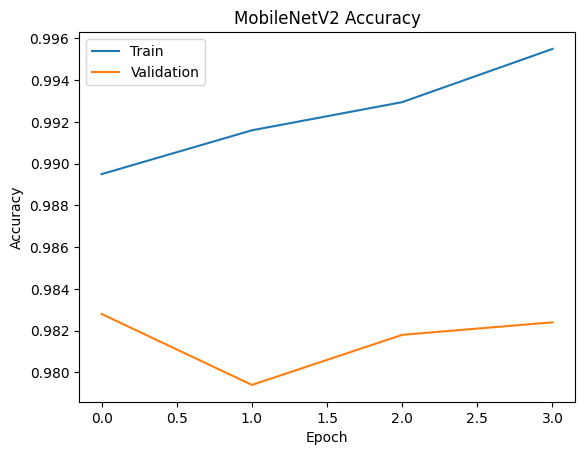

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

## Model 2: ResNet50 Transfer Learning

In [20]:
base_model2 = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model2.layers:
    layer.trainable = False

x = base_model2.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

resnet_model = Model(inputs=base_model2.input, outputs=output)

In [24]:
resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train ResNet50

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=3,              # wait 3 epochs before stopping
    restore_best_weights=True
)

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,               # maximum epochs
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 117ms/step - accuracy: 0.5757 - loss: 0.6788 - val_accuracy: 0.6604 - val_loss: 0.6255
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.6274 - loss: 0.6412 - val_accuracy: 0.6314 - val_loss: 0.6353
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 112ms/step - accuracy: 0.6327 - loss: 0.6355 - val_accuracy: 0.6402 - val_loss: 0.6254
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - accuracy: 0.6539 - loss: 0.6193 - val_accuracy: 0.6852 - val_loss: 0.6039
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 70s 113ms/step - accuracy: 0.6631 - loss: 0.6121 - val_accuracy: 0.6768 - val_loss: 0.6054
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.6663 - loss: 0.6092 - val_accuracy: 0.6624 - val_loss: 0.6071
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 114ms/step - accuracy: 0.6769 - loss: 0.6001 - val_accuracy: 0.6926 - val_loss: 0.5864
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.6811 - loss: 0

### ResNet50 Accuracy Graph

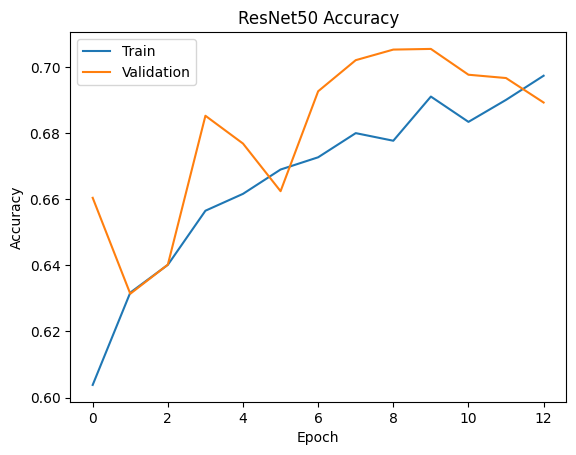

In [26]:
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

## Confusion Matrix and Classification Report

In [38]:
val_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col="image",
    y_col="labels",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 5000 validated image filenames belonging to 2 classes.


In [39]:
predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int)
true_classes = val_data.classes

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step


In [40]:
cm = confusion_matrix(true_classes, predicted_classes)

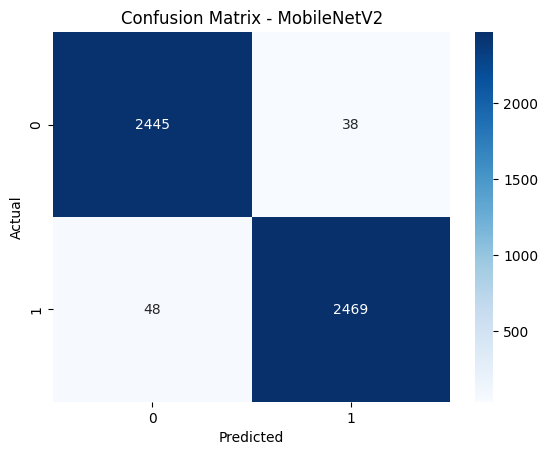

In [41]:
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

In [42]:
val_data = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col="image",
    y_col="labels",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 5000 validated image filenames belonging to 2 classes.


In [43]:
predictions_resnet = resnet_model.predict(val_data)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step


In [44]:
import numpy as np

predicted_classes_resnet = (predictions_resnet > 0.5).astype(int)

In [45]:
true_classes = val_data.classes

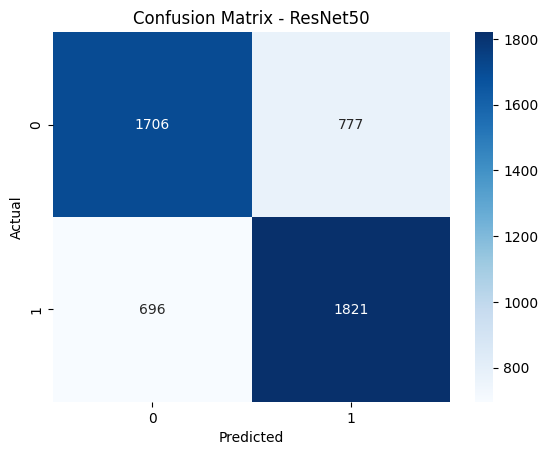

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_resnet = confusion_matrix(true_classes, predicted_classes_resnet)

sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")

plt.show()

In [47]:
print(classification_report(true_classes, predicted_classes, target_names=["Cat","Dog"]))

              precision    recall  f1-score   support

         Cat       0.98      0.98      0.98      2483
         Dog       0.98      0.98      0.98      2517

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



## Model Comparison

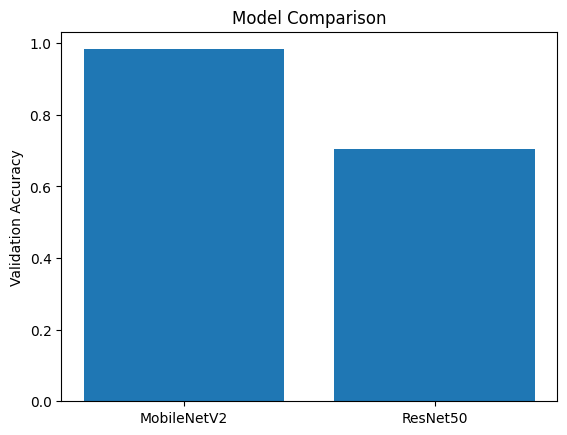

In [48]:
mobilenet_acc = max(history.history['val_accuracy'])
resnet_acc = max(history_resnet.history['val_accuracy'])
models = ["MobileNetV2","ResNet50"]
accuracy = [mobilenet_acc,resnet_acc]
plt.bar(models,accuracy)
plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")
plt.show()

## Save Trained Models

In [49]:
model.save("mobilenet_cat_dog_model.h5")
resnet_model.save("resnet_cat_dog_model.h5")